<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Copia_de_Sesion_04_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 4: Ejemplo de Clasificación

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 20 de enero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción a la Clasificación

### ¿Qué es la Clasificación?

La **clasificación** es una técnica de **aprendizaje supervisado** que predice una **categoría** o **clase**. A diferencia de la regresión (que predice un valor numérico continuo), la clasificación predice **a qué grupo pertenece** una observación.

```
REGRESIÓN                         CLASIFICACIÓN
═══════════════════════════════   ═══════════════════════════════

"¿Cuánto subirá/bajará?"          "¿Subirá o bajará?"

Predicción: +0.0023               Predicción: SUBE ✓
           -0.0015                            BAJA ✗
           +0.0008                            SUBE ✓

   Valor CONTINUO                    Valor DISCRETO
   (infinitos valores)               (número finito de clases)
```

### Tipos de Clasificación

```
CLASIFICACIÓN BINARIA             CLASIFICACIÓN MULTICLASE
═════════════════════             ════════════════════════

    Solo 2 clases:                    3 o más clases:

    • SUBE / BAJA                     • ALCISTA
    • COMPRAR / VENDER                • LATERAL
    • FRAUDE / NO FRAUDE              • BAJISTA
    • IMPAGO / NO IMPAGO

    ← Hoy nos centraremos aquí
```

### Aplicaciones en Finanzas

- **Predicción de dirección:** ¿El precio subirá o bajará mañana?
- **Detección de fraude:** ¿Esta transacción es fraudulenta?
- **Scoring crediticio:** ¿El cliente pagará o no pagará?
- **Señales de trading:** ¿Comprar, mantener o vender?

## 2. El Problema: ¿Por qué no usar Regresión Lineal?

Una primera idea sería usar la regresión lineal que aprendimos en la Sesión 3. Codificamos las clases como números (0 = BAJA, 1 = SUBE) y predecimos ese valor.

**¿Por qué esto NO funciona bien?**

```
EL PROBLEMA CON REGRESIÓN LINEAL PARA CLASIFICACIÓN
════════════════════════════════════════════════════

    Clase │
          │                           ────── Línea de regresión
       1  │  ■ ■ ■ ■ ■ ■ ■ ─────────────────────────▶ 1.5 ❌
          │              ╱
          │            ╱
    0.5   │─ ─ ─ ─ ─╱─ ─ ─ ─ ─ ─ ─ ─  (umbral de decisión)
          │        ╱
          │      ╱
       0  │────╱── □ □ □ □ □ □ □ ────────────────▶ -0.3 ❌
          └───────────────────────────────────────────▶
                            RSI

    PROBLEMAS:
    ❌ Las predicciones pueden ser > 1 (¿probabilidad del 150%?)
    ❌ Las predicciones pueden ser < 0 (¿probabilidad de -30%?)
    ❌ La relación entre features y probabilidad NO es lineal
```

**Necesitamos una función que:**
- ✅ Siempre devuelva valores entre 0 y 1
- ✅ Se pueda interpretar como probabilidad
- ✅ Capture la relación no lineal entre features y clases

## 3. La Solución: La Función Sigmoide

La **regresión logística** resuelve estos problemas usando la **función sigmoide** (también llamada función logística).

```
LA FUNCIÓN SIGMOIDE
═══════════════════

    Probabilidad │
                 │                          ┌───────── 1.0
            1.0  │                    ╭─────╯
                 │                 ╭──╯
                 │              ╭──╯
            0.5  │─ ─ ─ ─ ─ ─ ╳─ ─ ─ ─ ─ ─ ─  ← Punto de decisión
                 │          ╭─╯
                 │       ╭──╯
                 │    ╭──╯
            0.0  │────╯                       └───────── 0.0
                 └────────────────────────────────────────▶
                 -∞            0            +∞
                            z (combinación lineal)


    FÓRMULA:  σ(z) = 1 / (1 + e^(-z))

    Donde:    z = β₀ + β₁·RSI + β₂·Stoch + β₃·WillR + β₄·CCI


    PROPIEDADES CLAVE:
    ✓ Siempre entre 0 y 1 (interpretable como probabilidad)
    ✓ Cuando z → +∞, σ(z) → 1
    ✓ Cuando z → -∞, σ(z) → 0
    ✓ Cuando z = 0, σ(z) = 0.5 (punto de inflexión)
```

### ¿Cómo funciona la Regresión Logística?

```
PROCESO DE PREDICCIÓN
═════════════════════

    PASO 1: Combinación lineal (igual que regresión)
    ─────────────────────────────────────────────────
    z = β₀ + β₁·RSI + β₂·Stoch + β₃·WillR + β₄·CCI
    z = -2.1 + 0.03·45 + 0.02·60 + ... = 1.8


    PASO 2: Aplicar sigmoide (convertir a probabilidad)
    ───────────────────────────────────────────────────
    P(SUBE) = σ(1.8) = 1 / (1 + e^(-1.8)) = 0.86

    → 86% de probabilidad de que SUBA


    PASO 3: Clasificar según umbral
    ────────────────────────────────
    Si P(SUBE) > 0.5 → Predecir SUBE
    Si P(SUBE) ≤ 0.5 → Predecir BAJA

    Como 0.86 > 0.5 → Predicción: SUBE 🟢
```

## 4. Configuración del Entorno

In [ ]:
# ============================================================
# CONFIGURACIÓN INICIAL
# Ejecuta esta celda antes de continuar (Shift + Enter)
# ============================================================

# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Librerías de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


### Visualicemos la Función Sigmoide

Antes de continuar, veamos cómo luce realmente la función sigmoide:

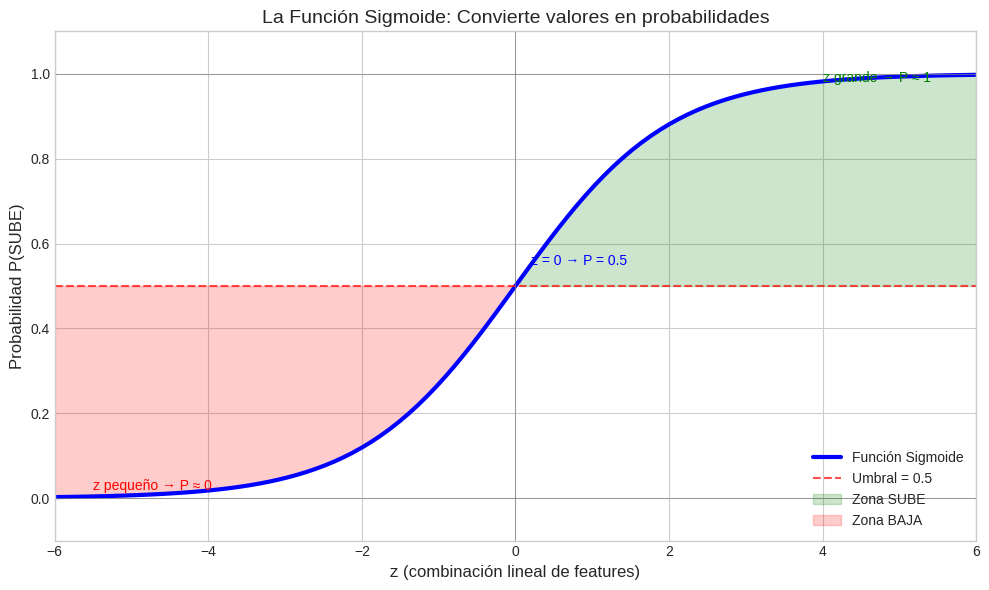


📊 La sigmoide 'aplasta' cualquier valor entre 0 y 1
   Esto nos permite interpretar la salida como PROBABILIDAD


In [ ]:
# ============================================================
# VISUALIZAR LA FUNCIÓN SIGMOIDE
# ============================================================

def sigmoide(z):
    """Función sigmoide: convierte cualquier valor en probabilidad [0,1]"""
    return 1 / (1 + np.exp(-z))

# Crear valores de z desde -6 hasta +6
z = np.linspace(-6, 6, 100)
prob = sigmoide(z)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Función sigmoide
ax.plot(z, prob, 'b-', linewidth=3, label='Función Sigmoide')

# Líneas de referencia
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Umbral = 0.5')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.axhline(y=1, color='gray', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

# Zonas de clasificación
ax.fill_between(z, 0.5, prob, where=(prob > 0.5), color='green', alpha=0.2, label='Zona SUBE')
ax.fill_between(z, prob, 0.5, where=(prob < 0.5), color='red', alpha=0.2, label='Zona BAJA')

# Etiquetas y título
ax.set_xlabel('z (combinación lineal de features)', fontsize=12)
ax.set_ylabel('Probabilidad P(SUBE)', fontsize=12)
ax.set_title('La Función Sigmoide: Convierte valores en probabilidades', fontsize=14)
ax.legend(loc='lower right')
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(-6, 6)

# Anotaciones
ax.annotate('z grande → P ≈ 1', xy=(4, 0.98), fontsize=10, color='green')
ax.annotate('z pequeño → P ≈ 0', xy=(-5.5, 0.02), fontsize=10, color='red')
ax.annotate('z = 0 → P = 0.5', xy=(0.2, 0.55), fontsize=10, color='blue')

plt.tight_layout()
plt.show()

print("\n📊 La sigmoide 'aplasta' cualquier valor entre 0 y 1")
print("   Esto nos permite interpretar la salida como PROBABILIDAD")

## 5. Cargar el Dataset

Usamos el mismo dataset de las sesiones anteriores: datos OHLCV del EUR/USD con indicadores técnicos.

In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df):,} filas")
print(f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columnas totales: {len(df.columns)}")
df.head()

Dataset cargado: 2,489 filas
Período: 2010-05-25 a 2019-12-30
Columnas totales: 501


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,...,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-25,1.23684,1.23715,1.21747,1.23423,24.421350,41.330435,-57.244898,-12631.780092,58.297675,33.900535,...,-91.817137,-2434.608816,7.508539,27.285877,11.662837,-91.817137,-2415.491160,5.800495,-0.013466,0
2010-05-26,1.23454,1.23870,1.21651,1.21761,8.540825,18.673390,-95.042812,-30614.995315,55.630696,18.773705,...,-98.637557,-2373.603625,7.537198,26.645143,6.291037,-98.637557,-2357.164021,5.842580,0.015128,1
2010-05-27,1.21776,1.23936,1.21498,1.23603,62.538188,44.684518,-13.658737,-27969.102260,58.252217,53.366665,...,-91.078464,-2322.459890,7.568027,28.524123,6.155614,-91.078464,-2306.098927,5.886673,-0.007330,0
2010-05-28,1.23585,1.24518,1.22614,1.22697,39.561528,43.666813,-60.298013,-62192.874981,43.837486,40.607390,...,-94.796454,-2278.999465,7.587006,28.165683,5.162508,-94.796454,-2260.232794,5.919011,0.002812,1
2010-05-31,1.22748,1.23335,1.22568,1.23042,52.775417,50.116981,-75.692308,-55713.249821,31.356454,47.743744,...,-93.380663,-2233.290788,7.606547,28.511223,6.914806,-93.380663,-2215.977269,5.951770,-0.006250,0


## 6. Crear el Target Binario

En la Sesión 3 usamos `Target_Return` (valor numérico). Ahora necesitamos convertirlo en una **clase binaria**:

```
CONVERSIÓN DE TARGET
════════════════════

Sesión 3 (Regresión)          Sesión 4 (Clasificación)
────────────────────          ────────────────────────
Target_Return = +0.0023   →   Target_Binario = 1 (SUBE)
Target_Return = -0.0015   →   Target_Binario = 0 (BAJA)
Target_Return = +0.0008   →   Target_Binario = 1 (SUBE)
Target_Return = -0.0042   →   Target_Binario = 0 (BAJA)

Regla simple: Si retorno > 0 → 1 (SUBE)
              Si retorno ≤ 0 → 0 (BAJA)
```

In [ ]:
# ============================================================
# CREAR TARGET BINARIO
# ============================================================

# Crear la columna Target_Binario
# 1 = el precio SUBE (retorno positivo)
# 0 = el precio BAJA (retorno negativo o cero)
df['Target_Binario'] = (df['Target_Return'] > 0).astype(int)

# Ver la distribución de clases
conteo = df['Target_Binario'].value_counts().sort_index()
total = len(df)

print("Distribución del Target Binario:")
print("=" * 40)
print(f"🔴 BAJA (0): {conteo[0]:,} días ({conteo[0]/total*100:.1f}%)")
print(f"🟢 SUBE (1): {conteo[1]:,} días ({conteo[1]/total*100:.1f}%)")
print("=" * 40)

Distribución del Target Binario:
🔴 BAJA (0): 1,237 días (49.7%)
🟢 SUBE (1): 1,252 días (50.3%)


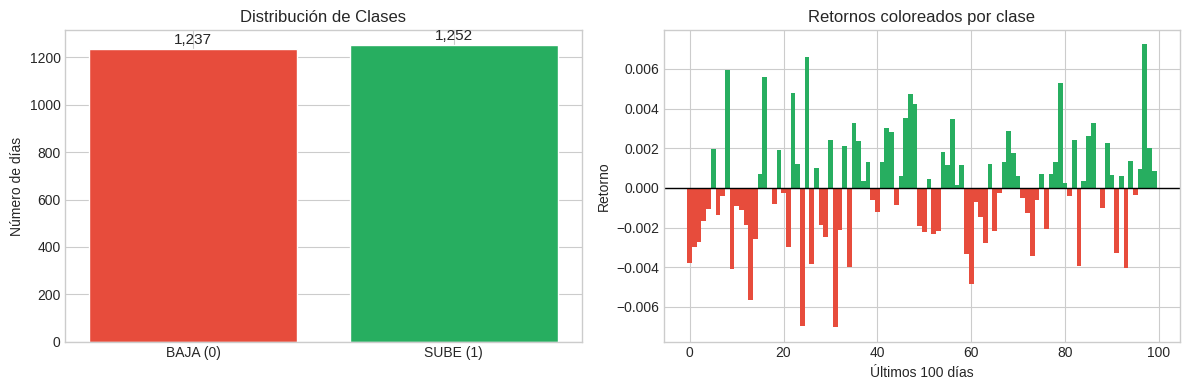


📊 Las clases están bastante equilibradas (~50/50)
   Esto es típico en mercados financieros eficientes


In [ ]:
# ============================================================
# VISUALIZAR DISTRIBUCIÓN DE CLASES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Barras
ax1 = axes[0]
colores = ['#e74c3c', '#27ae60']  # Rojo para BAJA, Verde para SUBE
barras = ax1.bar(['BAJA (0)', 'SUBE (1)'], conteo.values, color=colores, edgecolor='white')
ax1.set_ylabel('Número de días')
ax1.set_title('Distribución de Clases')
for barra, valor in zip(barras, conteo.values):
    ax1.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 20,
             f'{valor:,}', ha='center', fontsize=11)

# Gráfico 2: Serie temporal con colores
ax2 = axes[1]
ultimos_100 = df.tail(100)
colores_serie = ['#e74c3c' if x == 0 else '#27ae60' for x in ultimos_100['Target_Binario']]
ax2.bar(range(len(ultimos_100)), ultimos_100['Target_Return'], color=colores_serie, width=1.0)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_xlabel('Últimos 100 días')
ax2.set_ylabel('Retorno')
ax2.set_title('Retornos coloreados por clase')

plt.tight_layout()
plt.show()

print("\n📊 Las clases están bastante equilibradas (~50/50)")
print("   Esto es típico en mercados financieros eficientes")

## 7. Seleccionar Features

Usaremos las mismas 4 features que seleccionamos en la Sesión 3 (los indicadores direccionales con mejor correlación). Esto nos permite comparar directamente regresión vs clasificación.

In [ ]:
# ============================================================
# SELECCIONAR FEATURES (IGUAL QUE SESIÓN 3)
# ============================================================

# Indicadores direccionales (excluimos ADX que no predice dirección)
indicadores_direccionales = ['RSI', 'STOCH', 'WILLR', 'CCI']

# Encontrar el mejor periodo para cada indicador
# (el que tiene mayor correlación absoluta con Target_Return)
mejores_features = []

print("Seleccionando el mejor periodo por indicador:")
print("=" * 55)

for indicador in indicadores_direccionales:
    mejor_corr = 0
    mejor_periodo = 2

    for periodo in range(2, 101):
        col_name = f"{indicador}_{periodo}"
        if col_name in df.columns:
            corr = abs(df[col_name].corr(df['Target_Return']))
            if corr > mejor_corr:
                mejor_corr = corr
                mejor_periodo = periodo

    mejor_col = f"{indicador}_{mejor_periodo}"
    mejores_features.append(mejor_col)
    corr_real = df[mejor_col].corr(df['Target_Return'])
    print(f"  {indicador:8} → Periodo {mejor_periodo:3}  (correlación: {corr_real:+.4f})")

print("=" * 55)
print(f"\nFeatures seleccionadas: {mejores_features}")

Seleccionando el mejor periodo por indicador:
  RSI      → Periodo   2  (correlación: -0.0177)
  STOCH    → Periodo  15  (correlación: -0.0194)
  WILLR    → Periodo  16  (correlación: -0.0189)
  CCI      → Periodo  53  (correlación: +0.0177)

Features seleccionadas: ['RSI_2', 'STOCH_15', 'WILLR_16', 'CCI_53']


## 8. Preparar los Datos

Igual que en la sesión anterior, preparamos las matrices X (features) e y (target).

**Nota:** Para regresión logística, **no es estrictamente necesario escalar** los datos, pero puede mejorar la convergencia del algoritmo. Por simplicidad, no escalaremos.

In [ ]:
# ============================================================
# PREPARAR X (FEATURES) E Y (TARGET)
# ============================================================

# Crear matriz de features
X = df[mejores_features].copy()

# Crear vector target (ahora binario)
y = df['Target_Binario'].copy()

# Verificar dimensiones
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nFeatures utilizadas:")
for f in mejores_features:
    print(f"  • {f}")

print(f"\nTarget: 0 = BAJA, 1 = SUBE")

# Vista previa
print("\nVista previa de X:")
X.head()

Dimensiones de X: (2489, 4)
Dimensiones de y: (2489,)

Features utilizadas:
  • RSI_2
  • STOCH_15
  • WILLR_16
  • CCI_53

Target: 0 = BAJA, 1 = SUBE

Vista previa de X:


,RSI_2,STOCH_15,WILLR_16,CCI_53
Date,,,,
2010-05-25,24.421350,25.762708,-81.366227,-2350.183769
2010-05-26,8.540825,15.251200,-96.501212,-2238.406818
2010-05-27,62.538188,15.807777,-77.089261,-2152.437384
2010-05-28,39.561528,13.257456,-86.637159,-2087.926964
2010-05-31,52.775417,20.278595,-83.001370,-2034.694671


## 9. Entrenar el Modelo de Regresión Logística

Usaremos `LogisticRegression` de scikit-learn. ¡Es igual de simple que la regresión lineal!

In [ ]:
# ============================================================
# ENTRENAR MODELO DE REGRESIÓN LOGÍSTICA
# ============================================================

# Crear el modelo
modelo = LogisticRegression(random_state=42, max_iter=1000)

# Entrenar con los datos
modelo.fit(X, y)

print("✅ Modelo entrenado correctamente")
print("\n" + "=" * 50)
print("COEFICIENTES DEL MODELO")
print("=" * 50)
print(f"\nIntercepto (β₀): {modelo.intercept_[0]:.4f}")
print("\nCoeficientes (β):")
for feature, coef in zip(mejores_features, modelo.coef_[0]):
    signo = "+" if coef > 0 else ""
    print(f"  {feature:12} → {signo}{coef:.6f}")
print("=" * 50)

✅ Modelo entrenado correctamente

COEFICIENTES DEL MODELO

Intercepto (β₀): 0.7715

Coeficientes (β):
  RSI_2        → -0.004019
  STOCH_15     → -0.004597
  WILLR_16     → +0.004547
  CCI_53       → +0.000013


### Interpretación de los Coeficientes

A diferencia de la regresión lineal, los coeficientes de regresión logística NO se interpretan directamente como "cuánto cambia y por cada unidad de x".

```
INTERPRETACIÓN DE COEFICIENTES
══════════════════════════════

En regresión logística:

  β > 0  →  Mayor valor de X → Mayor probabilidad de SUBE
  β < 0  →  Mayor valor de X → Menor probabilidad de SUBE
  |β| grande  →  La variable tiene MUCHA influencia
  |β| pequeño →  La variable tiene POCA influencia
```

## 10. Realizar Predicciones

La regresión logística nos da **dos tipos de predicción**:
1. **Clase predicha:** SUBE (1) o BAJA (0)
2. **Probabilidad:** El valor entre 0 y 1 que indica la confianza

In [ ]:
# ============================================================
# REALIZAR PREDICCIONES
# ============================================================

# Predicción de clase (0 o 1)
y_pred = modelo.predict(X)

# Predicción de probabilidad
# predict_proba devuelve [P(BAJA), P(SUBE)]
probabilidades = modelo.predict_proba(X)
prob_sube = probabilidades[:, 1]  # Nos quedamos con P(SUBE)

# Añadir al DataFrame para análisis posterior
df['Prediccion_Clase'] = y_pred
df['Probabilidad_Sube'] = prob_sube

# Mostrar algunos ejemplos
print("Ejemplos de predicciones:")
print("=" * 70)
print(f"{'Fecha':<12} {'P(SUBE)':<10} {'Pred':<8} {'Real':<8} {'Correcto'}")
print("=" * 70)
for i in [0, 100, 500, 1000, 1500, 2000]:
    fecha = df.index[i].strftime('%Y-%m-%d')
    prob = df['Probabilidad_Sube'].iloc[i]
    pred = "SUBE" if df['Prediccion_Clase'].iloc[i] == 1 else "BAJA"
    real = "SUBE" if df['Target_Binario'].iloc[i] == 1 else "BAJA"
    correcto = "✓" if pred == real else "✗"
    print(f"{fecha:<12} {prob:<10.2%} {pred:<8} {real:<8} {correcto}")
print("=" * 70)

Ejemplos de predicciones:
Fecha        P(SUBE)    Pred     Real     Correcto
2010-05-25   53.83%     SUBE     BAJA     ✗
2010-10-12   50.50%     SUBE     SUBE     ✓
2012-04-24   46.74%     BAJA     SUBE     ✗
2014-04-02   50.36%     SUBE     BAJA     ✗
2016-03-08   47.30%     BAJA     BAJA     ✓
2018-02-09   54.89%     SUBE     SUBE     ✓


## 11. Visualizar la Sigmoide en Nuestros Datos

Veamos cómo la regresión logística ha aprendido a separar las clases usando uno de los indicadores:

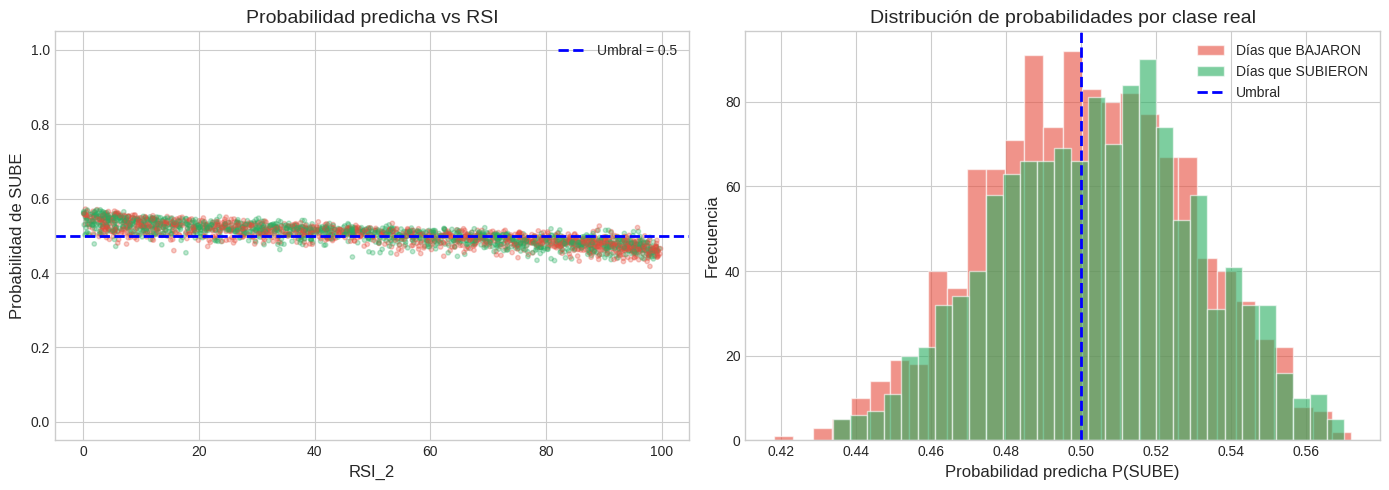


📊 Observaciones:
   • Hay superposición entre clases (mercados difíciles de predecir)
   • Probabilidades cercanas a 0.5 indican incertidumbre
   • Probabilidades extremas (cerca de 0 o 1) indican mayor confianza


In [ ]:
# ============================================================
# VISUALIZAR PROBABILIDADES VS RSI
# ============================================================

# Usamos RSI como ejemplo (primer indicador)
rsi_col = mejores_features[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Scatter de probabilidad vs RSI
ax1 = axes[0]
colores = ['#e74c3c' if c == 0 else '#27ae60' for c in df['Target_Binario']]
ax1.scatter(df[rsi_col], df['Probabilidad_Sube'], c=colores, alpha=0.3, s=10)
ax1.axhline(y=0.5, color='blue', linestyle='--', linewidth=2, label='Umbral = 0.5')
ax1.set_xlabel(f'{rsi_col}', fontsize=12)
ax1.set_ylabel('Probabilidad de SUBE', fontsize=12)
ax1.set_title('Probabilidad predicha vs RSI', fontsize=14)
ax1.legend()
ax1.set_ylim(-0.05, 1.05)

# Gráfico 2: Distribución de probabilidades
ax2 = axes[1]
ax2.hist(df[df['Target_Binario']==0]['Probabilidad_Sube'], bins=30, alpha=0.6,
         label='Días que BAJARON', color='#e74c3c', edgecolor='white')
ax2.hist(df[df['Target_Binario']==1]['Probabilidad_Sube'], bins=30, alpha=0.6,
         label='Días que SUBIERON', color='#27ae60', edgecolor='white')
ax2.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Umbral')
ax2.set_xlabel('Probabilidad predicha P(SUBE)', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title('Distribución de probabilidades por clase real', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n📊 Observaciones:")
print("   • Hay superposición entre clases (mercados difíciles de predecir)")
print("   • Probabilidades cercanas a 0.5 indican incertidumbre")
print("   • Probabilidades extremas (cerca de 0 o 1) indican mayor confianza")

## 12. Métricas de Evaluación para Clasificación

Las métricas de clasificación son diferentes a las de regresión. Las principales son:

```
MÉTRICAS DE CLASIFICACIÓN
═════════════════════════

1. ACCURACY (Exactitud)
   ────────────────────
   Accuracy = Predicciones correctas / Total
   
   Si accuracy = 0.55 → Acertamos el 55% de las veces


2. MATRIZ DE CONFUSIÓN
   ────────────────────
                        PREDICCIÓN
                      BAJA    SUBE
                  ┌─────────┬─────────┐
            BAJA  │   VN    │   FP    │   VN = Verdadero Negativo
   REAL           │ (acert) │ (error) │   FP = Falso Positivo
                  ├─────────┼─────────┤
            SUBE  │   FN    │   VP    │   FN = Falso Negativo
                  │ (error) │ (acert) │   VP = Verdadero Positivo
                  └─────────┴─────────┘
```

In [ ]:
# ============================================================
# CALCULAR MÉTRICAS DE CLASIFICACIÓN
# ============================================================

# Accuracy
accuracy = accuracy_score(y, y_pred)

# Matriz de confusión
cm = confusion_matrix(y, y_pred)
vn, fp, fn, vp = cm.ravel()

print("=" * 55)
print("MÉTRICAS DE CLASIFICACIÓN")
print("=" * 55)
print(f"\n🎯 ACCURACY: {accuracy:.2%}")
print(f"   ({accuracy*100:.1f}% de predicciones correctas)")
print("\n" + "=" * 55)
print("MATRIZ DE CONFUSIÓN")
print("=" * 55)
print(f"\n                    PREDICCIÓN")
print(f"                  BAJA      SUBE")
print(f"              ┌──────────┬──────────┐")
print(f"       BAJA   │  {vn:>5}   │  {fp:>5}   │")
print(f"REAL          │   (VN)   │   (FP)   │")
print(f"              ├──────────┼──────────┤")
print(f"       SUBE   │  {fn:>5}   │  {vp:>5}   │")
print(f"              │   (FN)   │   (VP)   │")
print(f"              └──────────┴──────────┘")
print("=" * 55)

# Interpretación
print(f"\n📊 Interpretación:")
print(f"   • Aciertos cuando BAJA:  {vn:,} días ({vn/(vn+fp)*100:.1f}%)")
print(f"   • Aciertos cuando SUBE:  {vp:,} días ({vp/(fn+vp)*100:.1f}%)")
print(f"   • Total aciertos:        {vn+vp:,} de {len(y):,}")

MÉTRICAS DE CLASIFICACIÓN

🎯 ACCURACY: 52.59%
   (52.6% de predicciones correctas)

MATRIZ DE CONFUSIÓN

                    PREDICCIÓN
                  BAJA      SUBE
              ┌──────────┬──────────┐
       BAJA   │    592   │    645   │
REAL          │   (VN)   │   (FP)   │
              ├──────────┼──────────┤
       SUBE   │    535   │    717   │
              │   (FN)   │   (VP)   │
              └──────────┴──────────┘

📊 Interpretación:
   • Aciertos cuando BAJA:  592 días (47.9%)
   • Aciertos cuando SUBE:  717 días (57.3%)
   • Total aciertos:        1,309 de 2,489


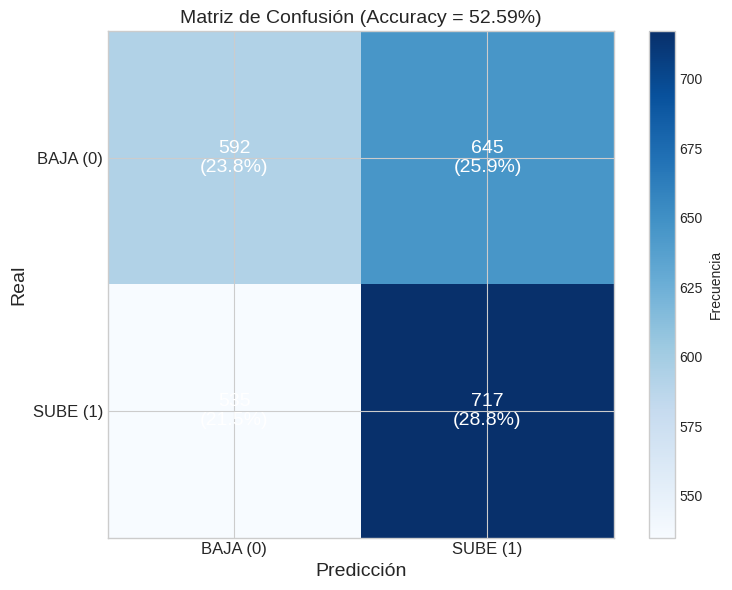

In [ ]:
# ============================================================
# VISUALIZAR MATRIZ DE CONFUSIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Crear heatmap manual
im = ax.imshow(cm, cmap='Blues')

# Etiquetas
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['BAJA (0)', 'SUBE (1)'], fontsize=12)
ax.set_yticklabels(['BAJA (0)', 'SUBE (1)'], fontsize=12)
ax.set_xlabel('Predicción', fontsize=14)
ax.set_ylabel('Real', fontsize=14)
ax.set_title(f'Matriz de Confusión (Accuracy = {accuracy:.2%})', fontsize=14)

# Añadir valores en las celdas
for i in range(2):
    for j in range(2):
        valor = cm[i, j]
        porcentaje = valor / len(y) * 100
        color = 'white' if valor > cm.max()/2 else 'black'
        ax.text(j, i, f'{valor:,}\n({porcentaje:.1f}%)',
                ha='center', va='center', fontsize=14, color=color)

plt.colorbar(im, ax=ax, label='Frecuencia')
plt.tight_layout()
plt.show()

## 13. Aplicación: Sistema de Trading Basado en Probabilidad

Ahora convertimos nuestras predicciones en un sistema de trading. La ventaja de la regresión logística es que podemos usar la **probabilidad** para decidir:

```
REGLAS DEL SISTEMA (Versión Simple)
════════════════════════════════════

Si P(SUBE) > 0.5  →  🟢 COMPRAR (LONG)
Si P(SUBE) < 0.5  →  🔴 VENDER (SHORT)
Si P(SUBE) = 0.5  →  ⚪ FUERA DEL MERCADO
```

In [ ]:
# ============================================================
# CREAR SISTEMA DE TRADING BASADO EN CLASIFICACIÓN
# ============================================================

# Generar señales basadas en la clase predicha
# +1 = LONG (predicción SUBE)
# -1 = SHORT (predicción BAJA)
df['Señal'] = np.where(df['Prediccion_Clase'] == 1, 1, -1)

# Calcular retorno del sistema
df['Retorno_Sistema'] = df['Señal'] * df['Target_Return']

# Calcular equity curves
df['Equity_Sistema'] = (1 + df['Retorno_Sistema']).cumprod()
df['Equity_BuyHold'] = (1 + df['Target_Return']).cumprod()

# Mostrar distribución de señales
print("Distribución de señales:")
print("=" * 40)
print(f"🟢 LONG (comprar):    {(df['Señal'] == 1).sum():,} días")
print(f"🔴 SHORT (vender):    {(df['Señal'] == -1).sum():,} días")
print("=" * 40)

Distribución de señales:
🟢 LONG (comprar):    1,362 días
🔴 SHORT (vender):    1,127 días


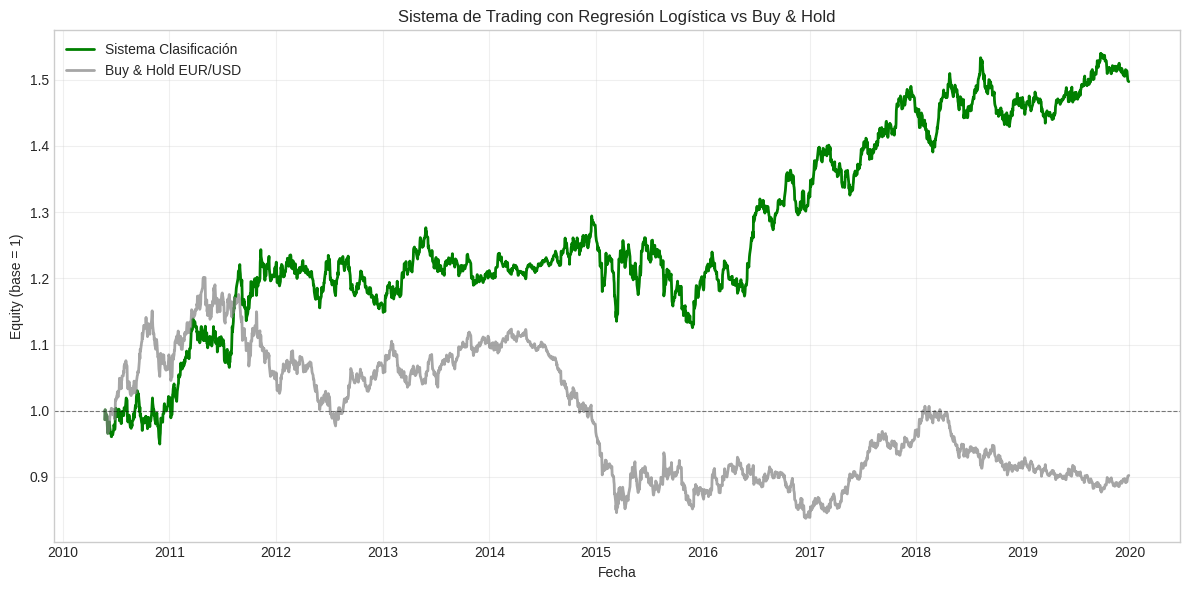

In [ ]:
# ============================================================
# GRÁFICO: EQUITY CURVE DEL SISTEMA
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df['Equity_Sistema'], label='Sistema Clasificación',
        linewidth=2, color='green')
ax.plot(df.index, df['Equity_BuyHold'], label='Buy & Hold EUR/USD',
        linewidth=2, color='gray', alpha=0.7)
ax.axhline(y=1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Fecha')
ax.set_ylabel('Equity (base = 1)')
ax.set_title('Sistema de Trading con Regresión Logística vs Buy & Hold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ESTADÍSTICAS DEL SISTEMA
# ============================================================

retorno_sistema = df['Equity_Sistema'].iloc[-1] - 1
retorno_buyhold = df['Equity_BuyHold'].iloc[-1] - 1
dias_totales = len(df)
dias_long = (df['Señal'] == 1).sum()
dias_short = (df['Señal'] == -1).sum()
retorno_medio_diario = df['Retorno_Sistema'].mean()

print("=" * 55)
print("ESTADÍSTICAS DEL SISTEMA DE CLASIFICACIÓN")
print("=" * 55)
print(f"\n📊 RENDIMIENTO")
print(f"   Retorno Sistema:      {retorno_sistema*100:+.2f}%")
print(f"   Retorno Buy & Hold:   {retorno_buyhold*100:+.2f}%")
print(f"   Diferencia:           {(retorno_sistema-retorno_buyhold)*100:+.2f}%")
print(f"\n📅 POSICIONAMIENTO")
print(f"   Días totales:         {dias_totales:,}")
print(f"   Días en LONG:         {dias_long:,} ({dias_long/dias_totales*100:.1f}%)")
print(f"   Días en SHORT:        {dias_short:,} ({dias_short/dias_totales*100:.1f}%)")
print(f"\n🎯 PRECISIÓN")
print(f"   Accuracy:             {accuracy:.2%}")
print(f"   Retorno medio diario: {retorno_medio_diario:.6f}")
print("=" * 55)

ESTADÍSTICAS DEL SISTEMA DE CLASIFICACIÓN

📊 RENDIMIENTO
   Retorno Sistema:      +49.71%
   Retorno Buy & Hold:   -9.77%
   Diferencia:           +59.49%

📅 POSICIONAMIENTO
   Días totales:         2,489
   Días en LONG:         1,362 (54.7%)
   Días en SHORT:        1,127 (45.3%)

🎯 PRECISIÓN
   Accuracy:             52.59%
   Retorno medio diario: 0.000177


## 14. Comparación: Clasificación vs Regresión

Comparemos el sistema de clasificación (Sesión 4) con el de regresión (Sesión 3):

In [ ]:
# ============================================================
# COMPARACIÓN: CLASIFICACIÓN VS REGRESIÓN
# ============================================================

print("=" * 60)
print("COMPARACIÓN: REGRESIÓN (Sesión 3) vs CLASIFICACIÓN (Sesión 4)")
print("=" * 60)
print(f"\n{'Aspecto':<30} {'Regresión':<15} {'Clasificación':<15}")
print("-" * 60)
print(f"{'¿Qué predice?':<30} {'Valor numérico':<15} {'Categoría':<15}")
print(f"{'Ejemplo de predicción':<30} {'+0.0023':<15} {'SUBE (87%)':<15}")
print(f"{'Algoritmo':<30} {'Lineal':<15} {'Logístico':<15}")
print(f"{'Función de salida':<30} {'Lineal':<15} {'Sigmoide':<15}")
print(f"{'Rango de salida':<30} {'(-∞, +∞)':<15} {'[0, 1]':<15}")
print(f"{'Métrica principal':<30} {'R², RMSE':<15} {'Accuracy':<15}")
print("-" * 60)
print(f"\n💡 Ambos enfoques son válidos para trading.")
print(f"   La clasificación es más directa: '¿compro o vendo?'")
print(f"   La regresión da más info: '¿cuánto espero ganar/perder?'")

COMPARACIÓN: REGRESIÓN (Sesión 3) vs CLASIFICACIÓN (Sesión 4)

Aspecto                        Regresión       Clasificación  
------------------------------------------------------------
¿Qué predice?                  Valor numérico  Categoría      
Ejemplo de predicción          +0.0023         SUBE (87%)     
Algoritmo                      Lineal          Logístico      
Función de salida              Lineal          Sigmoide       
Rango de salida                (-∞, +∞)        [0, 1]         
Métrica principal              R², RMSE        Accuracy       
------------------------------------------------------------

💡 Ambos enfoques son válidos para trading.
   La clasificación es más directa: '¿compro o vendo?'
   La regresión da más info: '¿cuánto espero ganar/perder?'


### ⚠️ Advertencia Importante

Este sistema es **puramente educativo**. Como en la sesión anterior, hemos cometido un error metodológico:

**Hemos entrenado y evaluado con los mismos datos.**

El modelo ha "visto" todos los datos y puede estar sobreajustado. En las próximas sesiones aprenderemos:

- **Sesión 8:** Partición In-Sample / Out-of-Sample
- **Sesión 9:** Sobreoptimización y validación cruzada

Por ahora, el objetivo es entender **cómo funciona la regresión logística**, no crear un sistema de trading rentable.

---

## Resumen de la Sesión

En esta sesión hemos aprendido:

✅ **Qué es la clasificación:** predecir categorías (SUBE/BAJA), no valores numéricos

✅ **El problema de usar regresión lineal:** las predicciones pueden salir del rango [0,1]

✅ **La función sigmoide:** convierte cualquier valor en una probabilidad entre 0 y 1

✅ **Regresión logística:** combina linealidad + sigmoide para clasificar

✅ **Métricas de clasificación:** Accuracy y Matriz de Confusión

✅ **Aplicación práctica:** sistema de trading basado en probabilidades

### Próxima Sesión

En la **Sesión 5 (23 de enero)** veremos **Árboles de Decisión**, un tipo de modelo completamente diferente que toma decisiones mediante preguntas secuenciales tipo "if-then-else".